In [1]:
init_notebook('us')
%kkmagic wide outall pdcols=50

Using logger config: /home/jingweiwu/pylog.conf


adjdb,TensorDB+axq.us-ropeknots://adjdb/v20210630/.adjdb.json
barradata,TensorDB+axq.us-ropeknots://barradata/v20220316/.barradata.json
currencydb,TensorDB+axq.us-ropeknots://currencydb/v20210630/.currencydb.json
dailypx,TensorDB+axq.us-ropeknots://dailypx/v20210630/.dailypx.json
dailypxret,TensorDB+axq.us-ropeknots://qrc/kaleido/v20230919/.dailypxret.json
earningscal,FrameDB+axq.us-ropeknots://earningscal/v20210630/.earningscal.json
fctcovar,TensorDB+axq.us-ropeknots://riskmodel/v20220316/.fctcovar.json
fctdb,TensorDB+axq.us-ropeknots://riskmodel/v20220316/.fctdb.json
fctexp,TensorDB+axq.us-ropeknots://riskmodel/v20220316/.fctexp.json
intradaypxret,TensorDB+axq.us-ropeknots://qrc/kaleido/v20240228/.intradaypxret.json
minidb,TensorDB+axq.us-ropeknots://minidb/v20211001/.minidb.json


Box(children=(Box(children=(Checkbox(value=True, description='show all output in a cell', indent=False), Check…

# peek at datasets

In [6]:
opprc = pd.read_parquet('/mnt/axq-personal/data/research/options/ivyopprcdb', filters=[('year', '=', 2010)])  # change to your local address
mktdata_sod = pd.read_parquet('/mnt/axq-personal/data/research/options/mktdata_sod/', filters=[('year', '=', 2010)])  # change to your local address
mktdata_eod = pd.read_parquet('/mnt/axq-personal/data/research/options/mktdata_eod/', filters=[('year', '=', 2010)])  # change to your local address
target0934 = pd.read_parquet('/mnt/axq-personal/data/research/options/future_res_0934/', filters=[('year', '=', 2010)])  # change to your local address
target1554 = pd.read_parquet('/mnt/axq-personal/data/research/options/future_res_1554/', filters=[('year', '=', 2010)])  # change to your local address 

In [16]:
opprc.head()
mktdata_sod.head()
mktdata_eod.head()
target0934.head()
target1554.head()

id  symbol  symbol_flag  strike  expiration_date  \
date     time                                                                 
20100122 79200000  1100000095  BUZ.CF        False    30.0         20100320   
         79200000  1100000095  BUZ.CG        False    35.0         20100320   
         79200000  1100000095  BUZ.CH        False    40.0         20100320   
         79200000  1100000095  BUZ.CI        False    45.0         20100320   
         79200000  1100000095  BUZ.CJ        False    50.0         20100320   

                  call_put  best_bid  best_offer last_trade_date  volume  \
date     time                                                              
20100122 79200000        C     11.80        15.8        20091006     0.0   
         79200000        C      7.80        10.3            None     0.0   
         79200000        C      4.10         6.1            None     0.0   
         79200000        C      1.75         3.0        20100113     0.0   
         79200000        C      0.25         1.5        20091028     0.0   

                   open_interest_lagged special_settlement  \
date     time                                                
20100122 79200000                   4.0                  1   
         79200000                   0.0                  1   
         79200000                   0.0                  1   
         79200000                   3.0                  1   
         79200000                 149.0                  1   

                   implied_volatility  delta  gamma  vega  theta  option_id  \
date     time                                                                 
20100122 79200000                 NaN    NaN    NaN   NaN    NaN   45423750   
         79200000                 NaN    NaN    NaN   NaN    NaN   45807992   
         79200000                 NaN    NaN    NaN   NaN    NaN   52450316   
         79200000                 NaN    NaN    NaN   NaN    NaN   45172981   
         79200000                 NaN    NaN    NaN   NaN    NaN   52450317   

                   adjustment_factor  am_settlement  contract_size  \
date     time                                                        
20100122 79200000                1.0          False          -99.0   
         79200000                1.0          False          -99.0   
         79200000                1.0          False          -99.0   
         79200000                1.0          False          -99.0   
         79200000                1.0          False          -99.0   

                  expiry_indicator  year  
date     time                             
20100122 79200000                   2010  
         79200000                   2010  
         79200000                   2010  
         79200000                   2010  
         79200000                   2010

spx    mid    sml    riy    rty    ray    ndx  \
date     time     id                                                            
20101209 32400000 1100000095  False  False  False  False  False  False  False   
                  1100000217  False  False  False  False  False  False  False   
                  1100000323  False   True  False  False   True   True  False   
                  1100000627  False  False  False  False   True   True  False   
                  1100000719  False  False  False  False   True   True  False   

                              spadr foreign ticker      cusip    sedol  \
date     time     id                                                     
20101209 32400000 1100000095  False    True    BTM  10553M101  2822031   
                  1100000217  False    True    ACH  022276109  2824628   
                  1100000323  False   False   MANT  564563104  2825308   
                  1100000627  False   False    FVE  33832D106  2826152   
                  1100000719  False   False    MCP  608753109  B458HM7   

                                      isin        id_bb_unique  \
date     time     id                                             
20101209 32400000 1100000095  US10553M1018  EQ0000000000041095   
                  1100000217  US0222761092  EQ0000000000047080   
                  1100000323  US5645631046  EQ0000000000050686   
                  1100000627  US33832D1063  EQ0000000000059456   
                  1100000719  US6087531090  EQ0000000000062696   

                             composite_id_bb_global barra_id id_bb_comp  \
date     time     id                                                      
20101209 32400000 1100000095           BBG000P6R062  USA4OZ1     173027   
                  1100000217           BBG000CMRVH1  USA4Q21    7257877   
                  1100000323           BBG000BGF8B5  USA4SS1    1139259   
                  1100000627           BBG000BJRQT7  USA4QI1    1753837   
                  1100000719           BBG000LBGTS0  USADFW1    7406383   

                             id_bb_sec                          name  \
date     time     id                                                   
20101209 32400000 1100000095      9000         BRASIL TELECOM SA-ADR   
                  1100000217      9000    ALUMINUM CORP OF CHINA-ADR   
                  1100000323      1000  MANTECH INTERNATIONAL CORP-A   
                  1100000627      1000        FIVE STAR QUALITY CARE   
                  1100000719      1000                  MOLYCORP INC   

                                               comp_name exch exch_mic  \
date     time     id                                                     
20101209 32400000 1100000095           Brasil Telecom SA   UN     XNYS   
                  1100000217  Aluminum Corp of China Ltd   UN     XNYS   
                  1100000323  Mantech International Corp   UW     XNGS   
                  1100000627  Five Star Quality Care Inc   UA     XASE   
                  1100000719                Molycorp Inc   UN     XNYS   

                              exch_name cntry              ind_sector  \
date     time     id                                                    
20101209 32400000 1100000095   New York    BR          Communications   
                  1100000217   New York    CN         Basic Materials   
                  1100000323  NASDAQ GS    US              Technology   
                  1100000627  NYSE Amex    US  Consumer, Non-cyclical   
                  1100000719   New York    US         Basic Materials   

                                        ind_group      sec_type market_status  \
date     time     id                                                            
20101209 32400000 1100000095   Telecommunications           ADR          ACTV   
                  1100000217               Mining           ADR          ACTV   
                  1100000323             Software  Common Stock          ACTV   
               

open     high      low    close    volume  \
date     time     id                                                       
20100618 79200000 1100000007  32.63  32.9300  32.5000  32.8500  207086.0   
                  1100000019  42.65  42.8700  42.5501  42.7700   32462.0   
                  1100000021  48.35  48.3819  48.1600  48.2144   12244.0   
                  1100000033  54.91  55.1400  54.7900  54.9900   22777.0   
                  1100000071  51.41  51.6605  51.4100  51.5500   35271.0   

                              sh_out_mm  sh_float_mm   beta    mktcap_mm  \
date     time     id                                                       
20100618 79200000 1100000007  30.750000    30.750000  0.994  1010.140015   
                  1100000019   5.599953     5.581000  1.001   239.509995   
                  1100000021  10.049902    10.049902  0.981   484.549988   
                  1100000033   9.300000     9.300000  1.039   511.410004   
                  1100000071   5.499903     5.499903  0.993   283.519989   

                              freefloat_mktcap_mm  addv5_mm  addv21_mm  \
date     time     id                                                     
20100618 79200000 1100000007          1010.137512  4.943107   6.052948   
                  1100000019           238.699371  2.034934   3.342000   
                  1100000021           484.549988  2.395825   4.077727   
                  1100000033           511.407013  2.041568   3.442969   
                  1100000071           283.519989  1.061690   1.856271   

                              addv63_mm  mddv5_mm  mddv21_mm  mddv63_mm  \
date     time     id                                                      
20100618 79200000 1100000007   5.857277  6.261605   4.911884   4.960054   
                  1100000019   2.984587  1.871281   2.168141   1.921185   
                  1100000021   4.144851  1.291897   2.725561   2.780255   
                  1100000033   4.157466  1.744390   2.043683   3.156060   
                  1100000071   3.040437  0.734043   1.331355   1.933151   

                              raw_c2c  res_c2c  year  
date     time     id                                  
20100618 79200000 1100000007      NaN      NaN  2010  
                  1100000019      NaN      NaN  2010  
                  1100000021      NaN      NaN  2010  
                  1100000033      NaN      NaN  2010  
                  1100000071      NaN      NaN  2010

specific_risk  future_res_t0  year
date     id                                            
20100104 1100000095       0.214614       0.004557  2010
         1100000217       0.183598       0.007839  2010
         1100000323       0.171300      -0.005683  2010
         1100000899       0.139715      -0.007335  2010
         1100001349       0.243824      -0.002086  2010

specific_risk  future_res_t0  future_res_t1  \
date     id                                                        
20100104 1100000095       0.214614      -0.000203       0.005901   
         1100000217       0.183598      -0.000213       0.080093   
         1100000323       0.171300      -0.000050      -0.006701   
         1100000899       0.139715      -0.000065      -0.006621   
         1100001349       0.243824       0.001209       0.006586   

                     future_res_t2  future_res_t3  future_res_t5  \
date     id                                                        
20100104 1100000095       0.038112       0.018868       0.018816   
         1100000217       0.086669       0.093160       0.123637   
         1100000323       0.003543       0.010444       0.017803   
         1100000899      -0.012288      -0.016473      -0.042455   
         1100001349       0.001955       0.009858      -0.034103   

                     future_res_t10  future_res_t15  future_res_t20  year  
date     id                                                                
20100104 1100000095       -0.150300       -0.185240       -0.209653  2010  
         1100000217        0.111537        0.074117        0.041198  2010  
         1100000323        0.025381        0.027633        0.021306  2010  
         1100000899       -0.033939       -0.067025       -0.065040  2010  
         1100001349       -0.000897       -0.035510       -0.016997  2010

# evaluate performance

We take 1-d reversal as an example to show how to evaluate performance

In [2]:
# load 3 year data, alpha is reversal of previous close-to-close return
univ = pd.read_parquet('/mnt/axq-personal/data/research/options/mktdata_sod/', columns=['spx', 'riy', 'ndx'], filters=[('year', '<', 2013)])  # change to your local address
alpha = pd.read_parquet('/mnt/axq-personal/data/research/options/mktdata_eod/', columns=['raw_c2c'], filters=[('year', '<', 2013)])  # change to your local address
target1554 = pd.read_parquet('/mnt/axq-personal/data/research/options/future_res_1554/', columns=['future_res_t1', 'future_res_t5'], filters=[('year', '<', 2013)])  # change to your local address 

alpha['alpha'] = -alpha['raw_c2c']

In [3]:
dates = alpha.eval('date').unique()
dates.sort()
# you can sanity check there should be 251 - 252 trading days each year
date_to_nextdate_map = dict(zip(dates[:-1], dates[1:]))

In [4]:
df = alpha[['alpha']].dropna().droplevel('time').reset_index()
df = df.loc[df['date'].isin(dates[:-1])]
df['date'] = df['date'].map(date_to_nextdate_map)  # shift date to next date as eod as equivalent to next day's sod
df = df.sort_values(['date', 'id']).set_index(['date', 'id'])

In [5]:
df = df.join(univ.droplevel('time')).join(target1554)

In [6]:
# quick calculation on correlation between our alpha and future returns
df[['alpha', 'future_res_t1', 'future_res_t5']].corr()
df.loc[df.spx | df.riy | df.ndx, ['alpha', 'future_res_t1', 'future_res_t5']].corr()

,alpha,future_res_t1,future_res_t5
alpha,1.000000,0.004192,0.003680
future_res_t1,0.004192,1.000000,0.444037
future_res_t5,0.003680,0.444037,1.000000


,alpha,future_res_t1,future_res_t5
alpha,1.000000,0.000606,0.001415
future_res_t1,0.000606,1.000000,0.447960
future_res_t5,0.001415,0.447960,1.000000


In [7]:
# precise calculation
df = df.loc[df.spx | df.riy | df.ndx].copy()
df['alpha_dot_future_res_t1'] = df['alpha'] * df['future_res_t1']
df['alpha_dot_future_res_t5'] = df['alpha'] * df['future_res_t5']
df['alpha_sq'] = df['alpha'] ** 2
df['future_res_t1_sq'] = df['future_res_t1'] ** 2
df['future_res_t5_sq'] = df['future_res_t5'] ** 2

In [8]:
ic1 = df.groupby('date')['alpha_dot_future_res_t1'].sum() / (df.groupby('date')['alpha_sq'].sum() * df.groupby('date')['future_res_t1_sq'].sum()) ** 0.5
ic5 = df.groupby('date')['alpha_dot_future_res_t5'].sum() / (df.groupby('date')['alpha_sq'].sum() * df.groupby('date')['future_res_t5_sq'].sum()) ** 0.5
ic = ic1.to_frame('ic1').join(ic5.to_frame('ic5'))

<AxesSubplot:xlabel='date'>

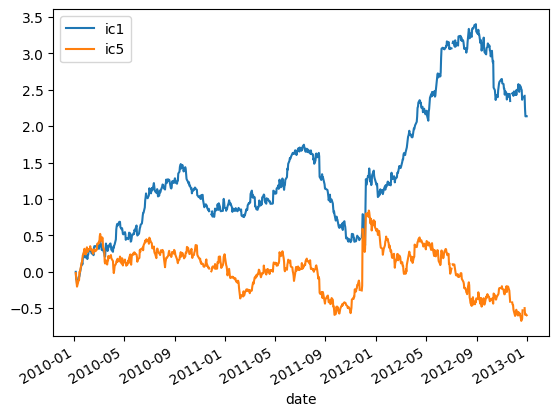

In [9]:
# plot ic time series
ic.index = pd.to_datetime(ic.index, format='%Y%m%d')
ic.cumsum().plot()